In [2]:
print("Hello")

Hello


In [3]:
import sys
print(sys.executable)

d:\projects\Heart Disease Prediction\.venv\Scripts\python.exe


In [4]:
import pandas as pd

In [5]:
df = pd.read_csv("../dataset/HeartDiseaseTrain-Test.csv")
df.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0


In [6]:
#df.shape
#df.columns
#df.dtypes
#df.info()
#df.describe()
#df.isnull().sum()
df.duplicated().sum()

np.int64(723)

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

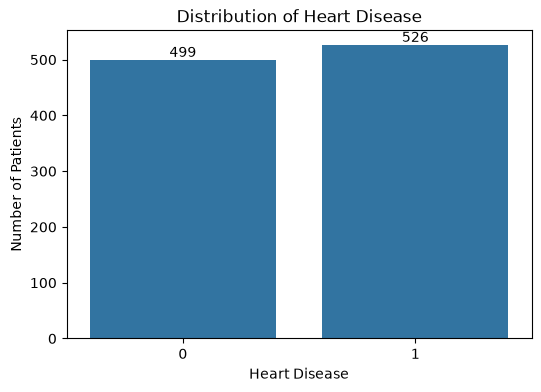

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

ax = sns.countplot(x='target', data=df)

plt.title("Distribution of Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")

# Display count on top of each bar
for container in ax.containers:
    ax.bar_label(container)
#plt.savefig("../images/age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

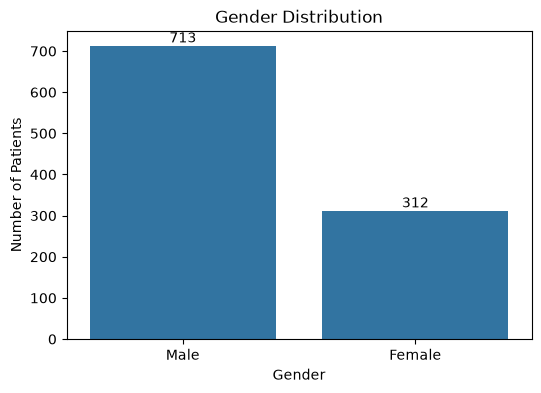

In [9]:
plt.figure(figsize=(6,4))

ax = sns.countplot(x='sex', data=df)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

for container in ax.containers:
    ax.bar_label(container)
#plt.savefig("../images/age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

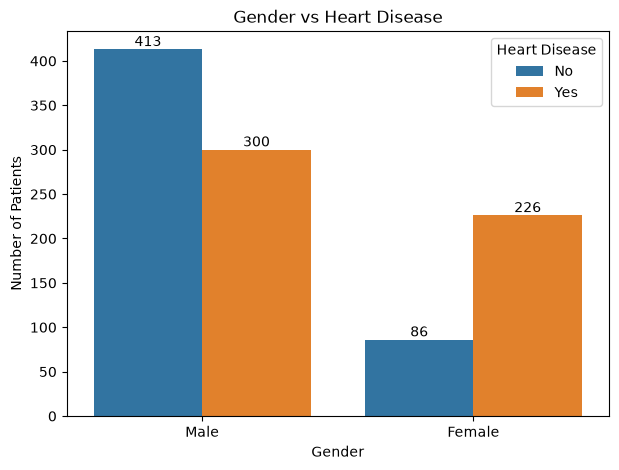

In [10]:
plt.figure(figsize=(7,5))

ax = sns.countplot(x='sex', hue='target', data=df)

plt.title("Gender vs Heart Disease")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

for container in ax.containers:
    ax.bar_label(container)

plt.legend(title="Heart Disease", labels=["No", "Yes"])
#plt.savefig("../images/age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

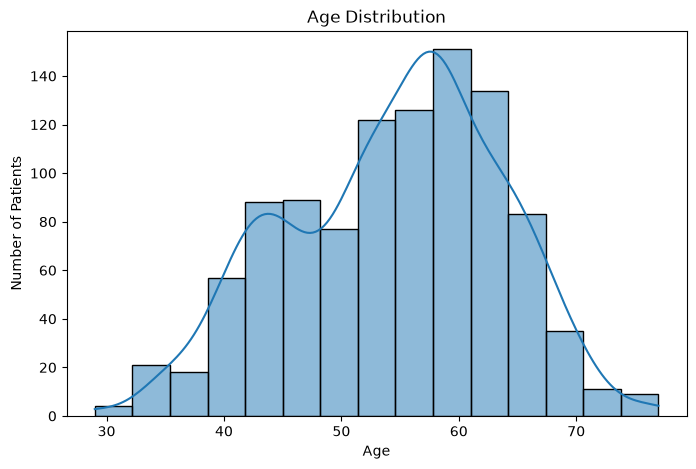

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=15, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
#plt.savefig("../images/age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

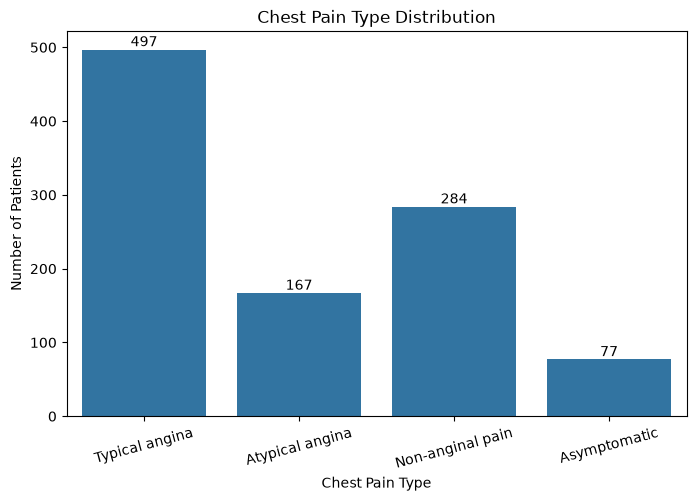

In [12]:
plt.figure(figsize=(8,5))

ax = sns.countplot(x='chest_pain_type', data=df)

plt.title("Chest Pain Type Distribution")
plt.xlabel("Chest Pain Type")
plt.ylabel("Number of Patients")

plt.xticks(rotation=15)

for container in ax.containers:
    ax.bar_label(container)
#plt.savefig("../images/age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

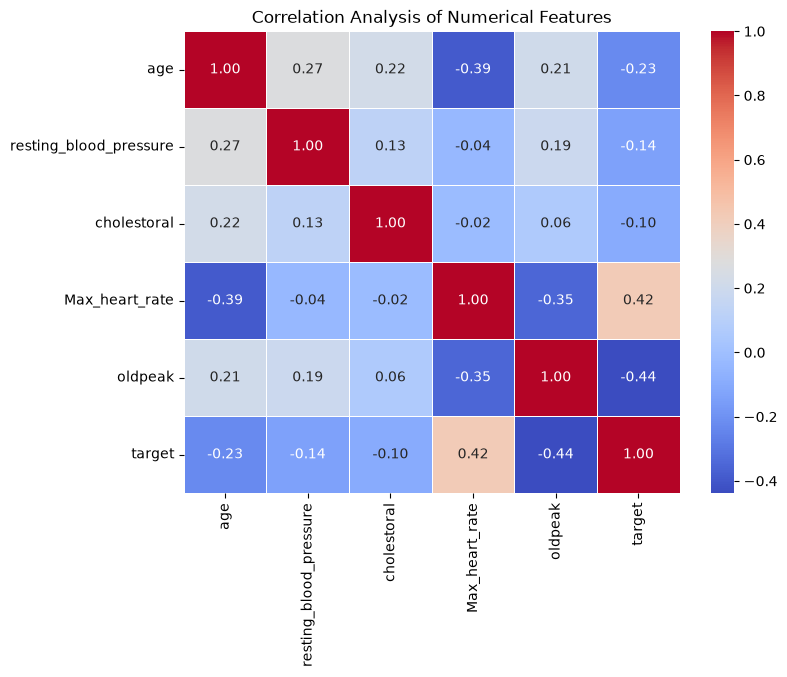

In [13]:
# Select only numerical columns
numerical_df = df.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
correlation = numerical_df.corr()

# Plot heatmap
plt.figure(figsize=(8,6))

sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5)

plt.title("Correlation Analysis of Numerical Features")
#plt.savefig("../images/age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

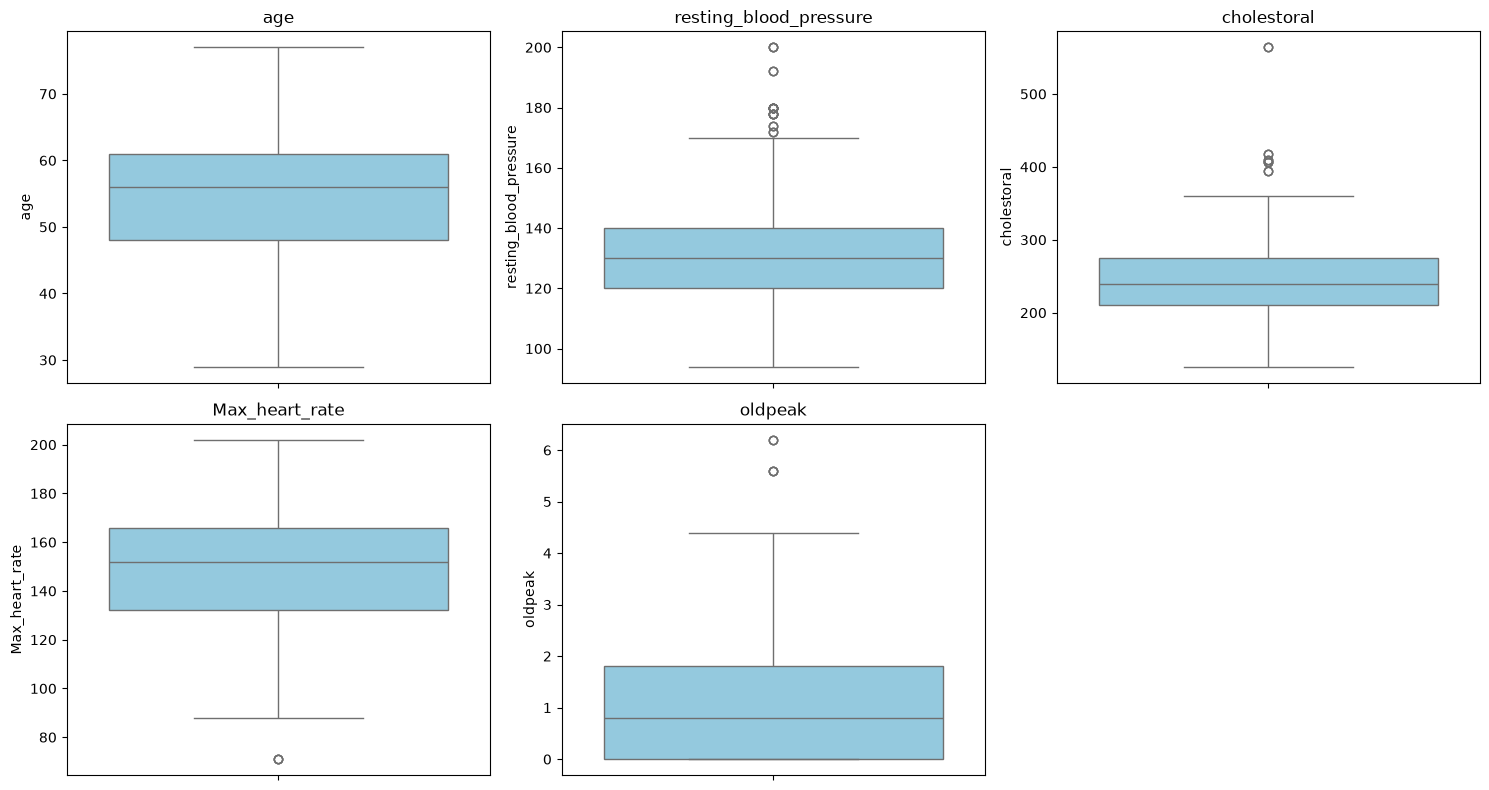

In [14]:
# List of numerical columns
numerical_columns = [
    'age',
    'resting_blood_pressure',
    'cholestoral',
    'Max_heart_rate',
    'oldpeak'
]

plt.figure(figsize=(15, 8))

for i, column in enumerate(numerical_columns, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[column], color='skyblue')
    plt.title(column)

plt.tight_layout()
#plt.savefig("../images/age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

C:\Users\rnklx\AppData\Local\Temp\ipykernel_9492\3746584625.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = heatmap_df.select_dtypes(include='object').columns


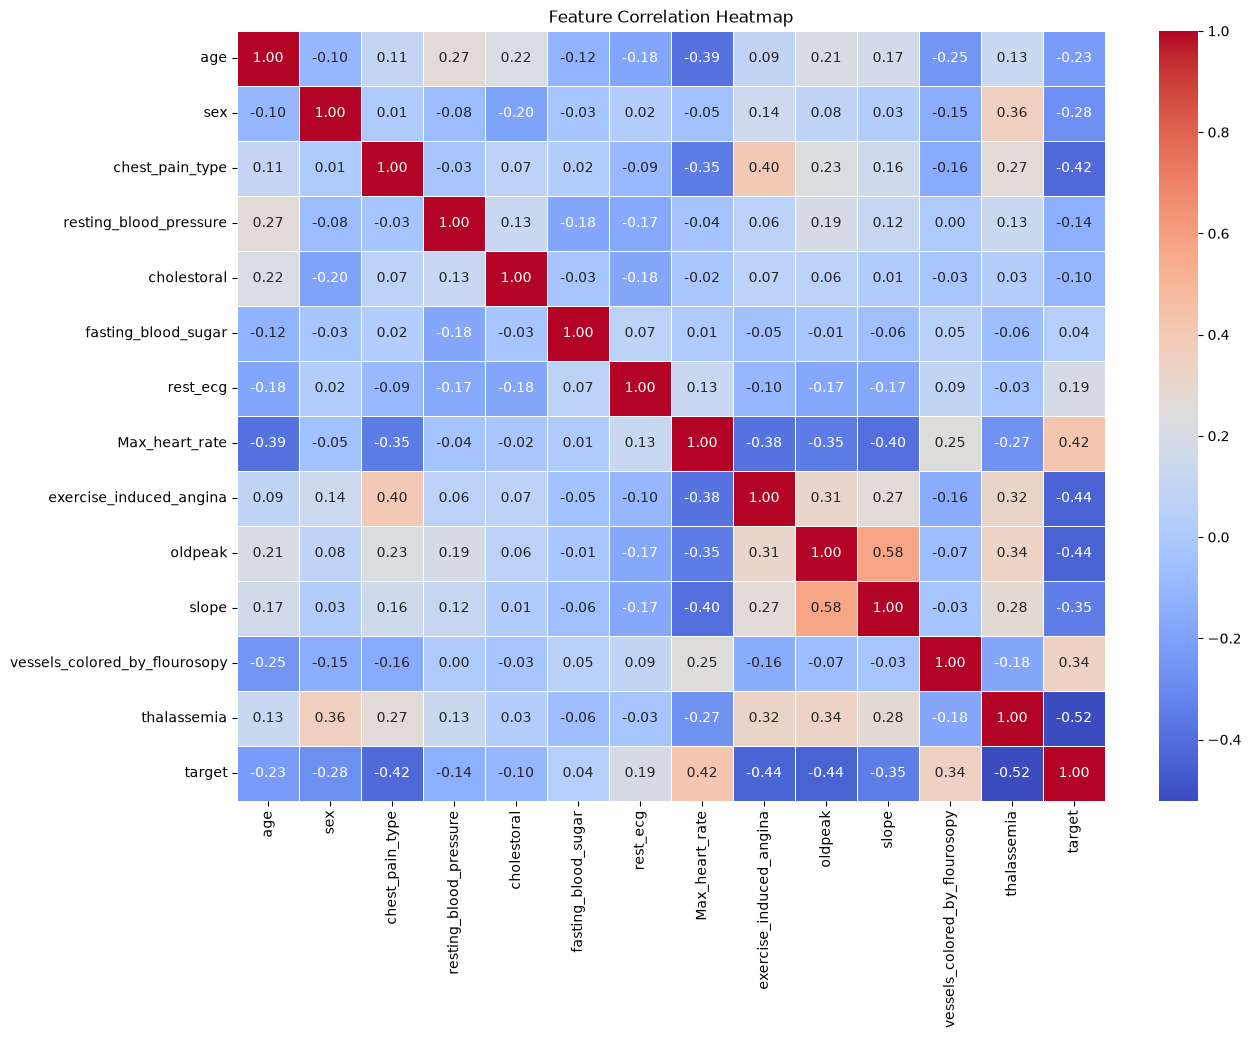

In [15]:
# Create a copy of the dataset
heatmap_df = df.copy()

# Convert categorical columns into numerical values
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = heatmap_df.select_dtypes(include='object').columns

for column in categorical_columns:
    heatmap_df[column] = le.fit_transform(heatmap_df[column])

# Plot heatmap
plt.figure(figsize=(14,10))

sns.heatmap(
    heatmap_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")
#plt.savefig("../images/age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
# Check dataset shape before removing duplicates
print("Shape before removing duplicates:", df.shape)

# Remove duplicate rows
df = df.drop_duplicates()

# Check dataset shape after removing duplicates
print("Shape after removing duplicates:", df.shape)

# Verify duplicates are removed
print("Remaining duplicate rows:", df.duplicated().sum())

Shape before removing duplicates: (1025, 14)
Shape after removing duplicates: (302, 14)
Remaining duplicate rows: 0


In [17]:
# Separate Features and Target

X = df.drop("target", axis=1)

y = df["target"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (302, 13)
Target Shape : (302,)


In [18]:
X.head()
y.head()

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

In [19]:
# Find categorical columns

categorical_columns = X.select_dtypes(include='object').columns

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
Index(['sex', 'chest_pain_type', 'fasting_blood_sugar', 'rest_ecg',
       'exercise_induced_angina', 'slope', 'vessels_colored_by_flourosopy',
       'thalassemia'],
      dtype='str')


C:\Users\rnklx\AppData\Local\Temp\ipykernel_9492\2379520654.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include='object').columns


In [20]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
for column in categorical_columns:
    X[column] = label_encoder.fit_transform(X[column])

In [25]:
# ================================
# DATA PREPROCESSING
# ================================

# Import required libraries
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# -------------------------------
# Separate Features and Target
# -------------------------------
X = df.drop("target", axis=1)
y = df["target"]

# -------------------------------
# Encode Categorical Features
# -------------------------------
label_encoder = LabelEncoder()

categorical_columns = X.select_dtypes(include="object").columns

for column in categorical_columns:
    X[column] = label_encoder.fit_transform(X[column])

# -------------------------------
# Feature Scaling
# -------------------------------
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# -------------------------------
# Train-Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# -------------------------------
# Display Results
# -------------------------------
print("Data Preprocessing Completed Successfully!\n")

print("Training Features Shape :", X_train.shape)
print("Testing Features Shape  :", X_test.shape)

print("Training Target Shape   :", y_train.shape)
print("Testing Target Shape    :", y_test.shape)

Data Preprocessing Completed Successfully!

Training Features Shape : (241, 13)
Testing Features Shape  : (61, 13)
Training Target Shape   : (241,)
Testing Target Shape    : (61,)


C:\Users\rnklx\AppData\Local\Temp\ipykernel_9492\4005865103.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include="object").columns


Logistic Regression Results

Accuracy : 0.8033

Confusion Matrix
[[21  7]
 [ 5 28]]

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.75      0.78        28
           1       0.80      0.85      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



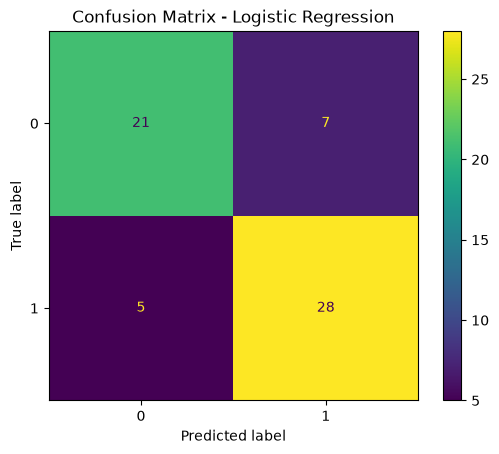

In [26]:
# ==========================================
# LOGISTIC REGRESSION MODEL
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Create Model
log_model = LogisticRegression(random_state=42)

# Train Model
log_model.fit(X_train, y_train)

# Predict
y_pred = log_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("="*50)
print("Logistic Regression Results")
print("="*50)

print(f"\nAccuracy : {accuracy:.4f}")

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

# Display Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

Decision Tree Results

Accuracy : 0.7377

Confusion Matrix
[[20  8]
 [ 8 25]]

Classification Report
              precision    recall  f1-score   support

           0       0.71      0.71      0.71        28
           1       0.76      0.76      0.76        33

    accuracy                           0.74        61
   macro avg       0.74      0.74      0.74        61
weighted avg       0.74      0.74      0.74        61



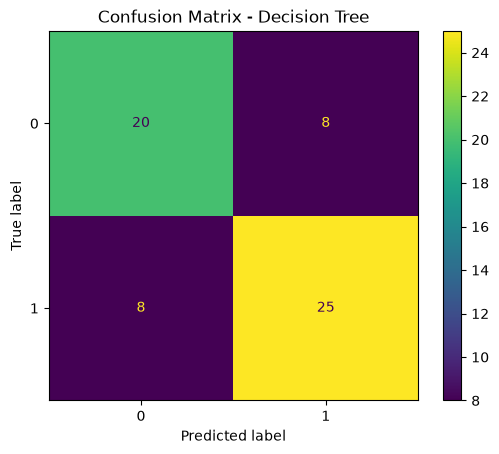

In [27]:
# ==========================================
# DECISION TREE MODEL
# ==========================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Create Model
dt_model = DecisionTreeClassifier(random_state=42)

# Train Model
dt_model.fit(X_train, y_train)

# Predict
y_pred_dt = dt_model.predict(X_test)

# Accuracy
accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("="*50)
print("Decision Tree Results")
print("="*50)

print(f"\nAccuracy : {accuracy_dt:.4f}")

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report")
print(classification_report(y_test, y_pred_dt))

# Display Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt)

plt.title("Confusion Matrix - Decision Tree")
plt.show()

Random Forest Results

Accuracy : 0.7869

Confusion Matrix
[[22  6]
 [ 7 26]]

Classification Report
              precision    recall  f1-score   support

           0       0.76      0.79      0.77        28
           1       0.81      0.79      0.80        33

    accuracy                           0.79        61
   macro avg       0.79      0.79      0.79        61
weighted avg       0.79      0.79      0.79        61



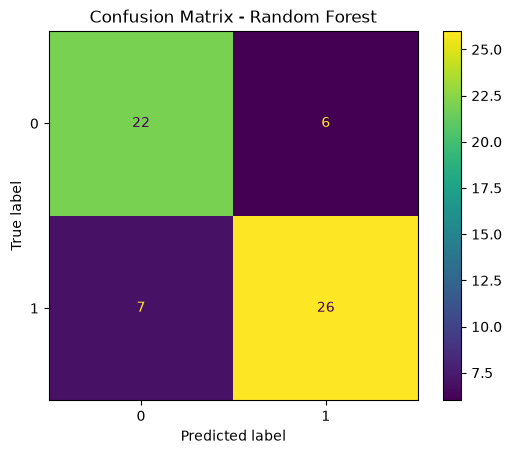

In [28]:
# ==========================================
# RANDOM FOREST MODEL
# ==========================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Create Model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train Model
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("="*50)
print("Random Forest Results")
print("="*50)

print(f"\nAccuracy : {accuracy_rf:.4f}")

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

# Display Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)

plt.title("Confusion Matrix - Random Forest")
plt.show()

K-Nearest Neighbors Results

Accuracy : 0.8525

Confusion Matrix
[[23  5]
 [ 4 29]]

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.82      0.84        28
           1       0.85      0.88      0.87        33

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



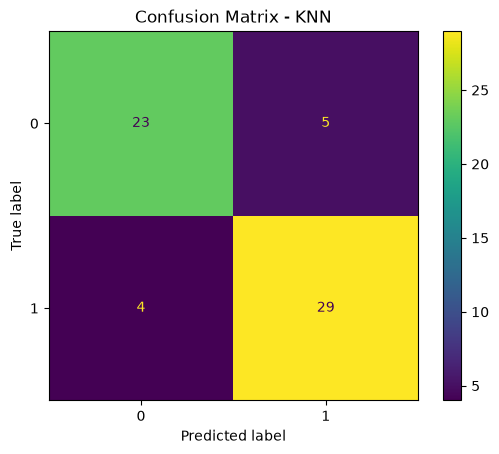

In [29]:
# ==========================================
# K-NEAREST NEIGHBORS (KNN) MODEL
# ==========================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Create Model
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train Model
knn_model.fit(X_train, y_train)

# Predict
y_pred_knn = knn_model.predict(X_test)

# Accuracy
accuracy_knn = accuracy_score(y_test, y_pred_knn)

print("="*50)
print("K-Nearest Neighbors Results")
print("="*50)

print(f"\nAccuracy : {accuracy_knn:.4f}")

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_knn))

print("\nClassification Report")
print(classification_report(y_test, y_pred_knn))

# Display Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn)

plt.title("Confusion Matrix - KNN")
plt.show()

Support Vector Machine Results

Accuracy : 0.7869

Confusion Matrix
[[21  7]
 [ 6 27]]

Classification Report
              precision    recall  f1-score   support

           0       0.78      0.75      0.76        28
           1       0.79      0.82      0.81        33

    accuracy                           0.79        61
   macro avg       0.79      0.78      0.78        61
weighted avg       0.79      0.79      0.79        61



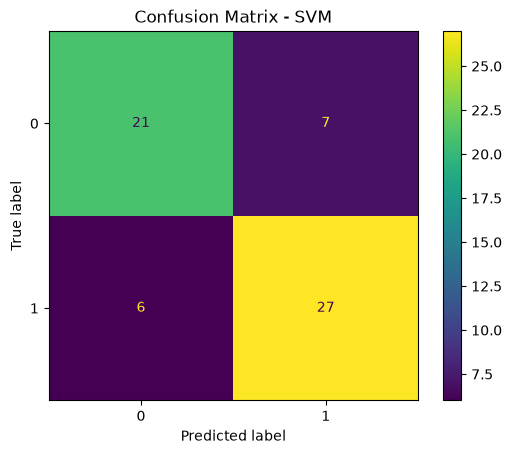

In [30]:
# ==========================================
# SUPPORT VECTOR MACHINE (SVM) MODEL
# ==========================================

from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Create Model
svm_model = SVC(kernel='rbf', random_state=42)

# Train Model
svm_model.fit(X_train, y_train)

# Predict
y_pred_svm = svm_model.predict(X_test)

# Accuracy
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("="*50)
print("Support Vector Machine Results")
print("="*50)

print(f"\nAccuracy : {accuracy_svm:.4f}")

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_svm))

print("\nClassification Report")
print(classification_report(y_test, y_pred_svm))

# Display Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm)

plt.title("Confusion Matrix - SVM")
plt.show()

Naive Bayes Results

Accuracy : 0.8033

Confusion Matrix
[[24  4]
 [ 8 25]]

Classification Report
              precision    recall  f1-score   support

           0       0.75      0.86      0.80        28
           1       0.86      0.76      0.81        33

    accuracy                           0.80        61
   macro avg       0.81      0.81      0.80        61
weighted avg       0.81      0.80      0.80        61



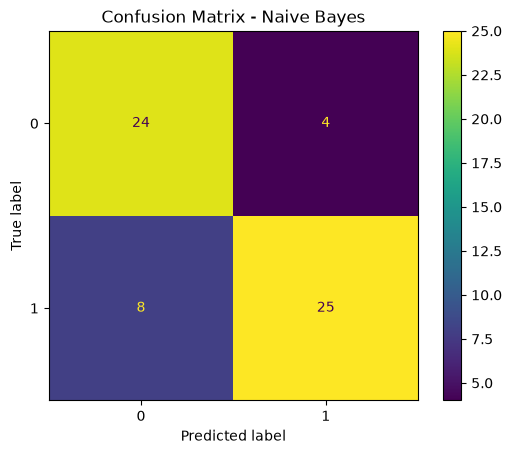

In [31]:
# ==========================================
# NAIVE BAYES MODEL
# ==========================================

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Create Model
nb_model = GaussianNB()

# Train Model
nb_model.fit(X_train, y_train)

# Predict
y_pred_nb = nb_model.predict(X_test)

# Accuracy
accuracy_nb = accuracy_score(y_test, y_pred_nb)

print("="*50)
print("Naive Bayes Results")
print("="*50)

print(f"\nAccuracy : {accuracy_nb:.4f}")

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_nb))

print("\nClassification Report")
print(classification_report(y_test, y_pred_nb))

# Display Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_nb)

plt.title("Confusion Matrix - Naive Bayes")
plt.show()

In [32]:
import joblib
import os

# Create models folder if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save trained Logistic Regression model
joblib.dump(log_model, "../models/logistic_regression_model.pkl")

# Save StandardScaler
joblib.dump(scaler, "../models/scaler.pkl")

print("Model Saved Successfully!")
print("Scaler Saved Successfully!")

Model Saved Successfully!
Scaler Saved Successfully!


In [33]:
# ==========================================
# SELECT IMPORTANT FEATURES
# ==========================================

# Selected important features
selected_features = [
    'age',
    'sex',
    'chest_pain_type',
    'Max_heart_rate',
    'exercise_induced_angina',
    'oldpeak',
    'slope',
    'vessels_colored_by_flourosopy',
    'thalassemia'
]

# Create new feature dataset
X_selected = df[selected_features]

# Target
y_selected = df['target']

print("Selected Features Shape :", X_selected.shape)

print("\nSelected Features:")
print(X_selected.columns)

Selected Features Shape : (302, 9)

Selected Features:
Index(['age', 'sex', 'chest_pain_type', 'Max_heart_rate',
       'exercise_induced_angina', 'oldpeak', 'slope',
       'vessels_colored_by_flourosopy', 'thalassemia'],
      dtype='str')


In [35]:
# ==========================================
# PREPROCESS THE SELECTED FEATURES
# ==========================================

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Make a copy
X_selected = X_selected.copy()

# Encode categorical columns
label_encoder = LabelEncoder()

categorical_columns = X_selected.select_dtypes(include='object').columns

for column in categorical_columns:
    X_selected[column] = label_encoder.fit_transform(X_selected[column])

# Scale data
scaler_selected = StandardScaler()

X_selected_scaled = scaler_selected.fit_transform(X_selected)

# Split data
X_train_selected, X_test_selected, y_train_selected, y_test_selected = train_test_split(
    X_selected_scaled,
    y_selected,
    test_size=0.20,
    random_state=42,
    stratify=y_selected
)

print("Preprocessing Completed Successfully!")

print("\nTraining Shape :", X_train_selected.shape)
print("Testing Shape  :", X_test_selected.shape)

Preprocessing Completed Successfully!

Training Shape : (241, 9)
Testing Shape  : (61, 9)


Logistic Regression (Selected Features)

Accuracy : 0.8033

Confusion Matrix
[[23  5]
 [ 7 26]]

Classification Report
              precision    recall  f1-score   support

           0       0.77      0.82      0.79        28
           1       0.84      0.79      0.81        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.81      0.80      0.80        61



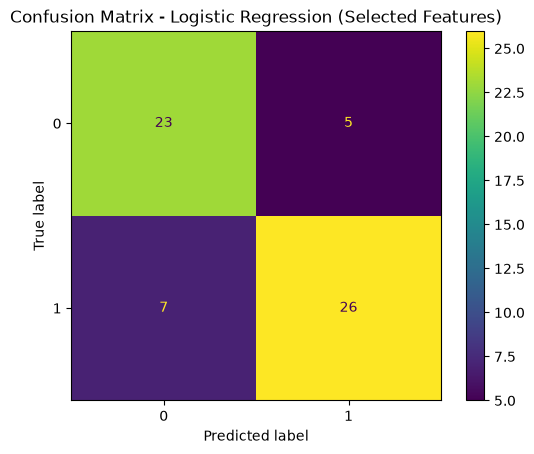

In [36]:
# ==========================================
# LOGISTIC REGRESSION (9 FEATURES)
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Create model
log_model_selected = LogisticRegression(random_state=42)

# Train
log_model_selected.fit(X_train_selected, y_train_selected)

# Predict
y_pred_selected = log_model_selected.predict(X_test_selected)

# Accuracy
accuracy_selected = accuracy_score(y_test_selected, y_pred_selected)

print("="*50)
print("Logistic Regression (Selected Features)")
print("="*50)

print(f"\nAccuracy : {accuracy_selected:.4f}")

print("\nConfusion Matrix")
print(confusion_matrix(y_test_selected, y_pred_selected))

print("\nClassification Report")
print(classification_report(y_test_selected, y_pred_selected))

ConfusionMatrixDisplay.from_predictions(
    y_test_selected,
    y_pred_selected
)

plt.title("Confusion Matrix - Logistic Regression (Selected Features)")
plt.show()

In [37]:
# ==========================================
# SAVE FINAL MODEL (9 FEATURES)
# ==========================================

import os
import joblib

# Create models folder
os.makedirs("../models", exist_ok=True)

# Save model
joblib.dump(log_model_selected, "../models/logistic_regression_model.pkl")

# Save scaler
joblib.dump(scaler_selected, "../models/scaler.pkl")

print("Final Logistic Regression Model Saved!")
print("Scaler Saved!")

Final Logistic Regression Model Saved!
Scaler Saved!
